<a href="https://colab.research.google.com/github/lzu1103/project/blob/main/%E6%B7%B1%E5%BA%A6%E5%AD%B8%E7%BF%92%E5%96%AE%E5%85%83%E4%BA%8C%E5%AF%A6%E9%A9%97%E4%BA%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2019 The TensorFlow Authors.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Convolutional Neural Network (CNN)

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/images/cnn">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/images/cnn.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/images/cnn.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/images/cnn.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates training a simple [Convolutional Neural Network](https://developers.google.com/machine-learning/glossary/#convolutional_neural_network) (CNN) to classify [CIFAR images](https://www.cs.toronto.edu/~kriz/cifar.html). Because this tutorial uses the [Keras Sequential API](https://www.tensorflow.org/guide/keras/overview), creating and training your model will take just a few lines of code.


### Import TensorFlow

In [ ]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

### Download and prepare the CIFAR10 dataset


The CIFAR10 dataset contains 60,000 color images in 10 classes, with 6,000 images in each class. The dataset is divided into 50,000 training images and 10,000 testing images. The classes are mutually exclusive and there is no overlap between them.

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 330s 2us/step


In [ ]:
print("訓練圖片形狀：", train_images.shape)
print("訓練標籤形狀：", train_labels.shape)
print("測試圖片形狀：", test_images.shape)
print("測試標籤形狀：", test_labels.shape)

print("圖片最小像素值：", train_images.min())
print("圖片最大像素值：", train_images.max())

訓練圖片形狀： (50000, 32, 32, 3)
訓練標籤形狀： (50000, 1)
測試圖片形狀： (10000, 32, 32, 3)
測試標籤形狀： (10000, 1)
圖片最小像素值： 0.0
圖片最大像素值： 1.0


資料集特徵

### Verify the data

To verify that the dataset looks correct, let's plot the first 25 images from the training set and display the class name below each image:


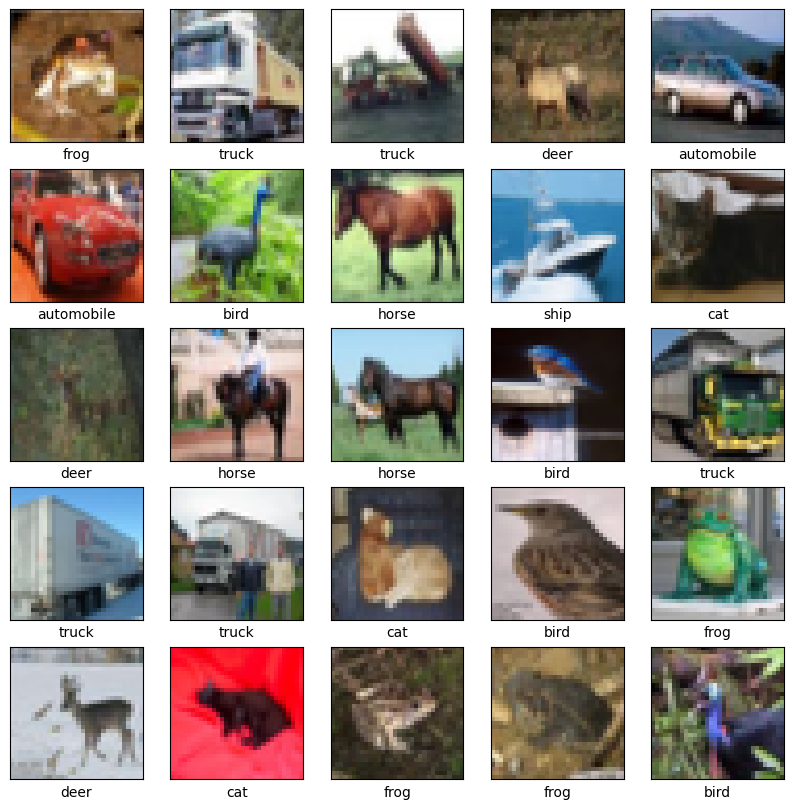

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

### Create the convolutional base

The 6 lines of code below define the convolutional base using a common pattern: a stack of [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) and [MaxPooling2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D) layers.

As input, a CNN takes tensors of shape (image_height, image_width, color_channels), ignoring the batch size. If you are new to these dimensions, color_channels refers to (R,G,B). In this example, you will configure your CNN to process inputs of shape (32, 32, 3), which is the format of CIFAR images. You can do this by passing the argument `input_shape` to your first layer.


In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


建立原始CNN

Let's display the architecture of your model so far:

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

Above, you can see that the output of every Conv2D and MaxPooling2D layer is a 3D tensor of shape (height, width, channels). The width and height dimensions tend to shrink as you go deeper in the network. The number of output channels for each Conv2D layer is controlled by the first argument (e.g., 32 or 64). Typically,  as the width and height shrink, you can afford (computationally) to add more output channels in each Conv2D layer.

### Add Dense layers on top

To complete the model, you will feed the last output tensor from the convolutional base (of shape (4, 4, 64)) into one or more Dense layers to perform classification. Dense layers take vectors as input (which are 1D), while the current output is a 3D tensor. First, you will flatten (or unroll) the 3D output to 1D,  then add one or more Dense layers on top. CIFAR has 10 output classes, so you use a final Dense layer with 10 outputs.

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

加入Dense分類層

Here's the complete architecture of your model:

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

The network summary shows that (4, 4, 64) outputs were flattened into vectors of shape (1024) before going through two Dense layers.

### Compile and train the model

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4470 - loss: 1.5141 - val_accuracy: 0.5427 - val_loss: 1.2643
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5907 - loss: 1.1480 - val_accuracy: 0.6236 - val_loss: 1.0626
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6476 - loss: 1.0009 - val_accuracy: 0.6609 - val_loss: 0.9700
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6824 - loss: 0.8979 - val_accuracy: 0.6802 - val_loss: 0.9180
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7098 - loss: 0.8222 - val_accuracy: 0.6840 - val_loss: 0.8994
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7319 - loss: 0.7635 - val_accuracy: 0.7117 - val_loss: 0.8470
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7512 - loss: 0.7135 - val_accuracy: 0.7045 - val_loss: 0.8628
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7643 - loss: 0.6688 -

### Evaluate the model

313/313 - 1s - 2ms/step - accuracy: 0.7116 - loss: 0.8867


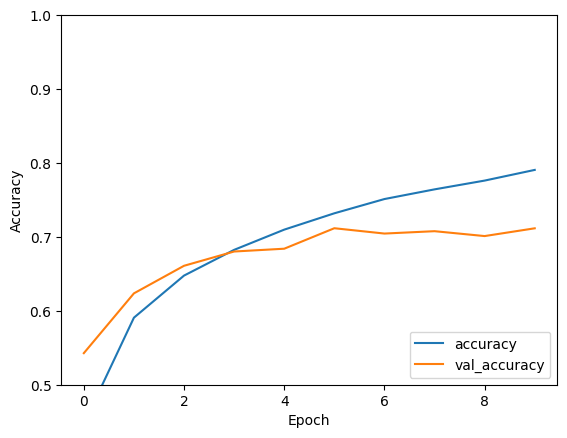

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=2
)
train_loss, train_acc = model.evaluate(
    train_images,
    train_labels,
    verbose=0
)

In [ ]:
print(f"原始模型 Training Loss：{train_loss:.4f}")
print(f"原始模型 Training Accuracy：{train_acc:.4f}（{train_acc * 100:.2f}%）")

print(f"原始模型 Test Loss：{test_loss:.4f}")
print(f"原始模型 Test Accuracy：{test_acc:.4f}（{test_acc * 100:.2f}%）")

原始模型 Training Loss：0.5149
原始模型 Training Accuracy：0.8187（81.87%）
原始模型 Test Loss：0.8867
原始模型 Test Accuracy：0.7116（71.16%）


In [ ]:
improved_model = models.Sequential()

改良版CNN模型

In [ ]:
# 建立資料增強模型
data_augmentation = models.Sequential([
    # 隨機將圖片左右翻轉
    layers.RandomFlip("horizontal"),

    # 隨機將圖片上下、左右平移最多10%
    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1,
        fill_mode="reflect"
    )
], name="data_augmentation")

增強分類能力

In [ ]:
improved_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # 對訓練圖片進行隨機翻轉和平移
    data_augmentation,

    # 第一個卷積區塊：32個Filters
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    # 第二個卷積區塊：64個Filters
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    # 第三個卷積區塊：128個Filters
    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    # 將三維特徵圖攤平成一維
    layers.Flatten(),

    # 使用256個神經元整合前面擷取到的特徵
    layers.Dense(
        units=256,
        use_bias=False,
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    # 10個類別
    layers.Dense(
        units=10,
        activation="softmax"
    )
])

建立改良CNN架構

In [ ]:
improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 816,234 (3.11 MB)

 Trainable params: 814,826 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=["accuracy"]
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/best_cifar10_improved.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=0.000001,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
improved_history = improved_model.fit(
    train_images,
    train_labels,

    epochs=60,
    batch_size=64,

    validation_data=(
        test_images,
        test_labels
    ),

    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop
    ]
)

Epoch 1/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3345 - loss: 1.9367
Epoch 1: val_accuracy improved from None to 0.48600, saving model to /content/best_cifar10_improved.keras

Epoch 1: finished saving model to /content/best_cifar10_improved.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.4106 - loss: 1.6543 - val_accuracy: 0.4860 - val_loss: 1.4035 - learning_rate: 0.0010
Epoch 2/60
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5224 - loss: 1.3169
Epoch 2: val_accuracy improved from 0.48600 to 0.61980, saving model to /content/best_cifar10_improved.keras

Epoch 2: finished saving model to /content/best_cifar10_improved.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.5495 - loss: 1.2520 - val_accuracy: 0.6198 - val_loss: 1.0655 - learning_rate: 0.0010
Epoch 3/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6064 - loss: 1.1035
Epoch 3: val_accuracy improved from 0.61980 to 0.68380, saving model to /content/best_cifar10_

In [ ]:
# 評估
improved_train_loss, improved_train_acc = improved_model.evaluate(
    train_images,
    train_labels,
    verbose=0
)
improved_test_loss, improved_test_acc = improved_model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(
    f"改良模型 Training Loss："
    f"{improved_train_loss:.4f}"
)

print(
    f"改良模型 Training Accuracy："
    f"{improved_train_acc:.4f}"
    f"（{improved_train_acc * 100:.2f}%）"
)

print(
    f"改良模型 Test Loss："
    f"{improved_test_loss:.4f}"
)

print(
    f"改良模型 Test Accuracy："
    f"{improved_test_acc:.4f}"
    f"（{improved_test_acc * 100:.2f}%）"
)

改良模型 Training Loss：0.2381
改良模型 Training Accuracy：0.9159（91.59%）
改良模型 Test Loss：0.3675
改良模型 Test Accuracy：0.8779（87.79%）


In [ ]:
print(
    f"原始模型 Training Accuracy："
    f"{train_acc * 100:.2f}%"
)

print(
    f"原始模型 Test Accuracy："
    f"{test_acc * 100:.2f}%"
)
print()

print(
    f"Training Accuracy 提升："
    f"{(improved_train_acc - train_acc) * 100:.2f} 個百分點"
)

print(
    f"Test Accuracy 提升："
    f"{(improved_test_acc - test_acc) * 100:.2f} 個百分點"
)

原始模型 Training Accuracy：81.87%
原始模型 Test Accuracy：71.16%

Training Accuracy 提升：9.72 個百分點
Test Accuracy 提升：16.63 個百分點


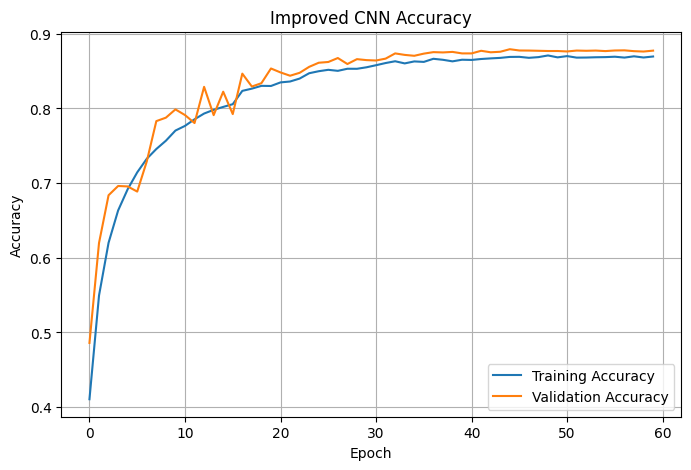

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    improved_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN Accuracy")
plt.legend()
plt.grid()
plt.show()

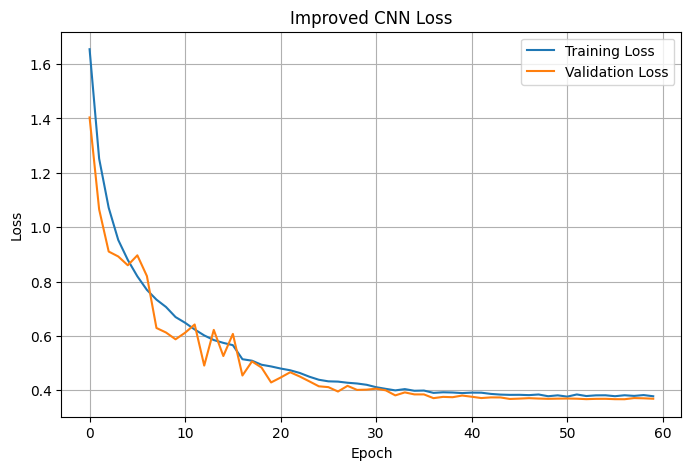

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    improved_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CNN Loss")
plt.legend()
plt.grid()
plt.show()

Your simple CNN has achieved a test accuracy of over 70%. Not bad for a few lines of code! For another CNN style, check out the [TensorFlow 2 quickstart for experts](https://www.tensorflow.org/tutorials/quickstart/advanced) example that uses the Keras subclassing API and `tf.GradientTape`.